<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/_train_1s_30hz_initial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR Training

In [3]:
# For VSCode
%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

with open('../data_1s_30hz_real_world/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../data_1s_30hz_real_world/X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('../data_1s_30hz_real_world/X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('../data_1s_30hz_real_world/y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

np_train_data.shape, np_val_data.shape, np_test_labels.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


((352, 30, 3), (89, 30, 3), (111, 2))

In [ ]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys
sys.path.append('../../')
from utils.preprocessing import *



seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/X_test_data.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

print(np_train_data.shape, np_train_labels.shape)
print(np_val_data.shape, np_val_labels.shape)

fatal: destination path 'Bachelorarbeit' already exists and is not an empty directory.
--2025-09-30 13:46:47--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1900965 (1.8M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   1.81M  --.-KB/s    in 0.04s   

2025-09-30 13:46:48 (43.8 MB/s) - ‘X_train_normalized.pkl’ saved [1900965/1900965]

--2025-09-30 13:46:48--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 18

## 1.1 assaign label to y_train, y_val with trained model

In [5]:
# Load the pre-trained model
model_path = "../models/20251001-132548_simclr_full_eval.keras"
har_best_model = tf.keras.models.load_model(model_path)

# Make predictions on training and validation data
train_predictions = har_best_model.predict(np_train_data)
val_predictions = har_best_model.predict(np_val_data)

# Print shapes to verify
print("\nData Shapes:")
print(f"Training predictions shape: {train_predictions.shape}")
print(f"Validation predictions shape: {val_predictions.shape}")


 1/11 ━━━━━━━━━━━━━━━━━━━━ 3s 335ms/step

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Data Shapes:

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)



Training predictions shape: (352, 2)
Validation predictions shape: (89, 2)


## 1.2 Fine-tuning and Evaluation

### 1.2.1 Linear Model

#### Train

In [7]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 200
tag = "linear_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')

In [9]:
# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model_save_path = "../models/20251001-132548_simclr_2class_30hz_1s.hdf5"
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 730ms/step - auc: 0.5123 - categorical_accuracy: 0.5233 - loss: 0.6980 - precision: 0.5233 - recall: 0.5233 - val_auc: 0.6622 - val_categorical_accuracy: 0.5843 - val_loss: 0.6343 - val_precision: 0.5843 - val_recall: 0.5843
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - auc: 0.7618 - categorical_accuracy: 0.6860 - loss: 0.5886 - precision: 0.6860 - recall: 0.6860 - val_auc: 0.7374 - val_categorical_accuracy: 0.6629 - val_loss: 0.6235 - val_precision: 0.6629 - val_recall: 0.6629
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - auc: 0.7967 - categorical_accuracy: 0.7330 - loss: 0.5747 - precision: 0.7330 - recall: 0.7330 - val_auc: 0.7317 - val_categorical_accuracy: 0.6629 - val_loss: 0.6197 - val_precision: 0.6629 - val_recall: 0.6629
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - auc: 0.8166 - categorical_accuracy: 0.7498 - loss: 0.5576 - precision: 0.7498 - recall: 0.7498 - val_auc: 0.7332 - val_categorical_accuracy: 0.6742 - val_loss: 0.6178 

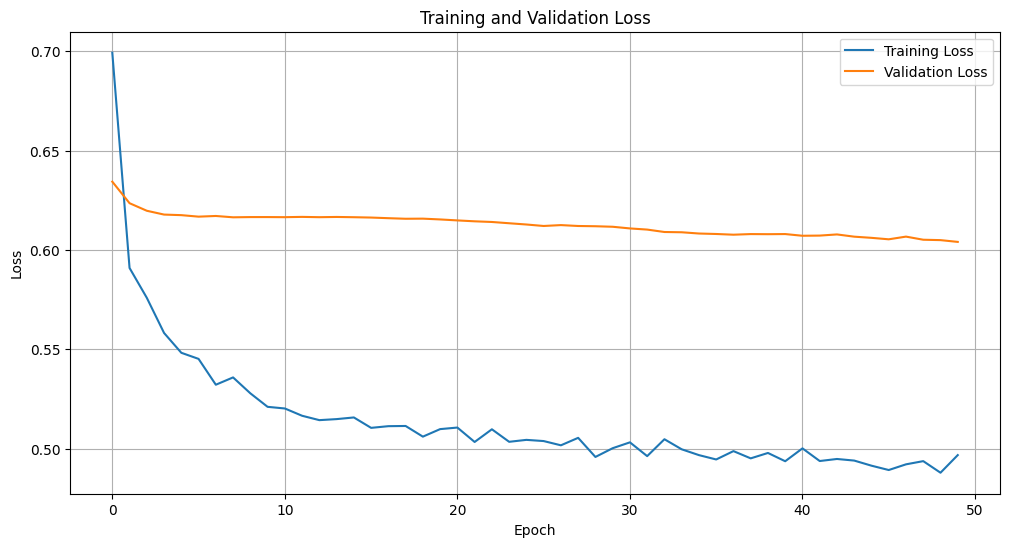

In [10]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

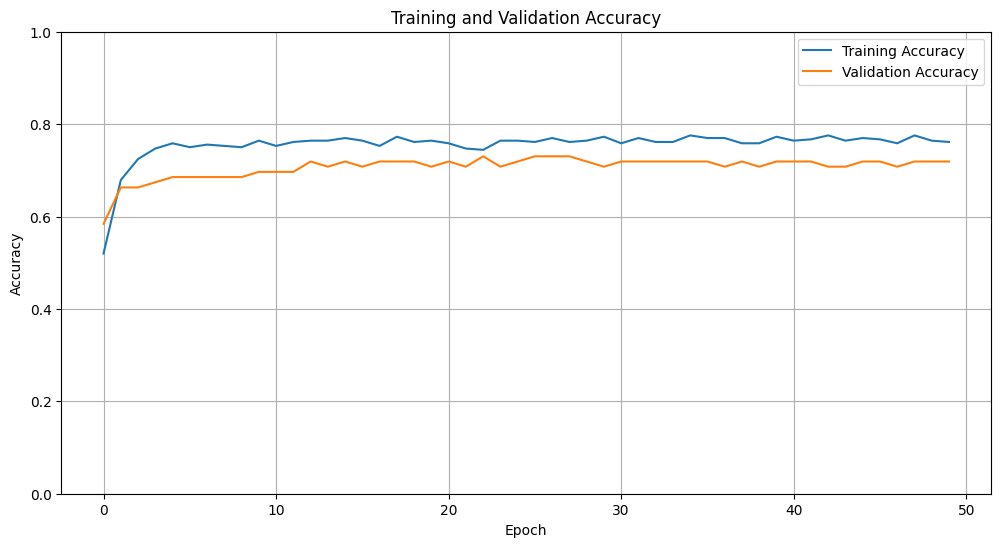

In [11]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [12]:
# Load models and evaluate on test set on vscode
linear_eval_model_path =  linear_eval_best_model_file_name

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

#### Normalize test data

In [13]:
# You can also use it for test data (but should fit the scaler only on training data)
X_test_normalized = normalize_3d_data(np_test_data)

In [14]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
{'Confusion Matrix': array([[49,  6],
       [17, 39]]), 'F1 Macro': 0.7910972915473365, 'F1 Micro': 0.7927927927927928, 'F1 Weighted': 0.790927741422791, 'Precision': 0.8045454545454546, 'Recall': 0.7936688311688311, 'Kappa': np.float64(0.5862907146329606)}

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)



Model in last epoch


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/stepWARNING:tensorflow:6 out of the last 22 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001440F0659E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
{'Confusion Matrix': array([[49,  6],
       [17, 39]]), 'F1 Macro': 0.7910972915473365, 'F1 Micro': 0.7927927927927928, 'F1 Weighted': 0.790927741422791, 'Precision': 0.8045454545454546, 'Recall': 0.7936688311688311, 'Kappa': np.float64(0.5862907146329606)}


### 1.2.2 Full HAR Model

#### Train

In [15]:
total_epochs = 50
batch_size = 200
tag = "full_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 788ms/step - auc: 0.6688 - categorical_accuracy: 0.6024 - loss: 0.6788 - precision: 0.6024 - recall: 0.6024 - val_auc: 0.6954 - val_categorical_accuracy: 0.6292 - val_loss: 0.6748 - val_precision: 0.6292 - val_recall: 0.6292
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - auc: 0.8034 - categorical_accuracy: 0.7360 - loss: 0.5458 - precision: 0.7360 - recall: 0.7360 - val_auc: 0.7358 - val_categorical_accuracy: 0.7191 - val_loss: 0.6639 - val_precision: 0.7191 - val_recall: 0.7191
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - auc: 0.8016 - categorical_accuracy: 0.7505 - loss: 0.5652 - precision: 0.7505 - recall: 0.7505 - val_auc: 0.7418 - val_categorical_accuracy: 0.6629 - val_loss: 0.6815 - val_precision: 0.6629 - val_recall: 0.6629
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - auc: 0.8371 - categorical_accuracy: 0.7538 - loss: 0.5271 - precision: 0.7538 - recall: 0.7538 - val_auc: 0.7533 - val_categorical_accuracy: 0.6742 - val_loss: 0.6672 -

#### Plot metrics

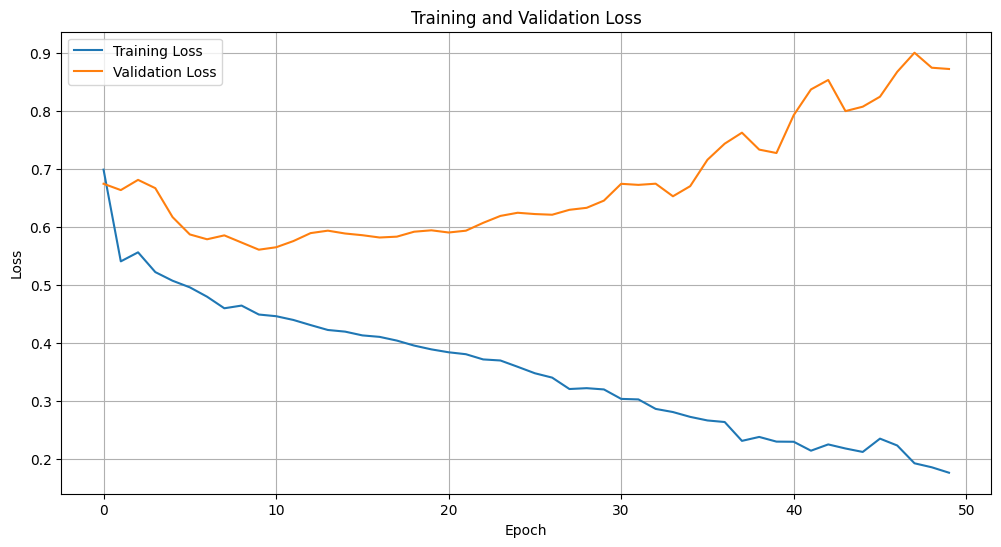

In [18]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

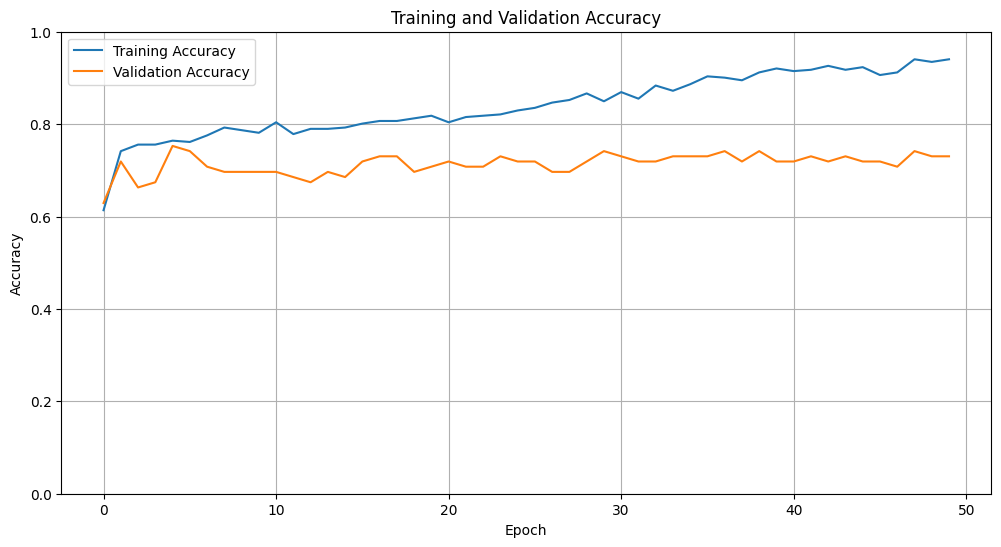

In [19]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [20]:
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


{'Confusion Matrix': array([[50,  5],
       [20, 36]]), 'F1 Macro': 0.7711340206185567, 'F1 Micro': 0.7747747747747747, 'F1 Weighted': 0.7708739667502553, 'Precision': 0.7961672473867596, 'Recall': 0.775974025974026, 'Kappa': np.float64(0.5506072874493928)}
Model in last epoch
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
{'Confusion Matrix': array([[48,  7],
       [15, 41]]), 'F1 Macro': 0.8010104302477183, 'F1 Micro': 0.8018018018018018, 'F1 Weighted': 0.8008973771685636, 'Precision': 0.8080357142857142, 'Recall': 0.8024350649350649, 'Kappa': np.float64(0.6040856031128404)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


## Extra: t-SNE Plots

### Parameters

In [21]:
import sklearn.manifold
import seaborn as sns

### t-SNE Representations

In [22]:
# First load the model from the file path
target_model_path = simclr_model_save_path
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(X_test_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(111, 30, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 111 samples in 0.000s...
[t-SNE] Computed neighbors for 111 samples in 0.441s...
[t-SNE] Computed conditional probabilities for sample 111 / 111
[t-SNE] Mean sigma: 1.675642
[t-SNE] KL divergence after 250 iterations with early exaggeration: 48.769272
[t-SNE] KL divergence after 1000 iterations: 0.116068


### Plotting

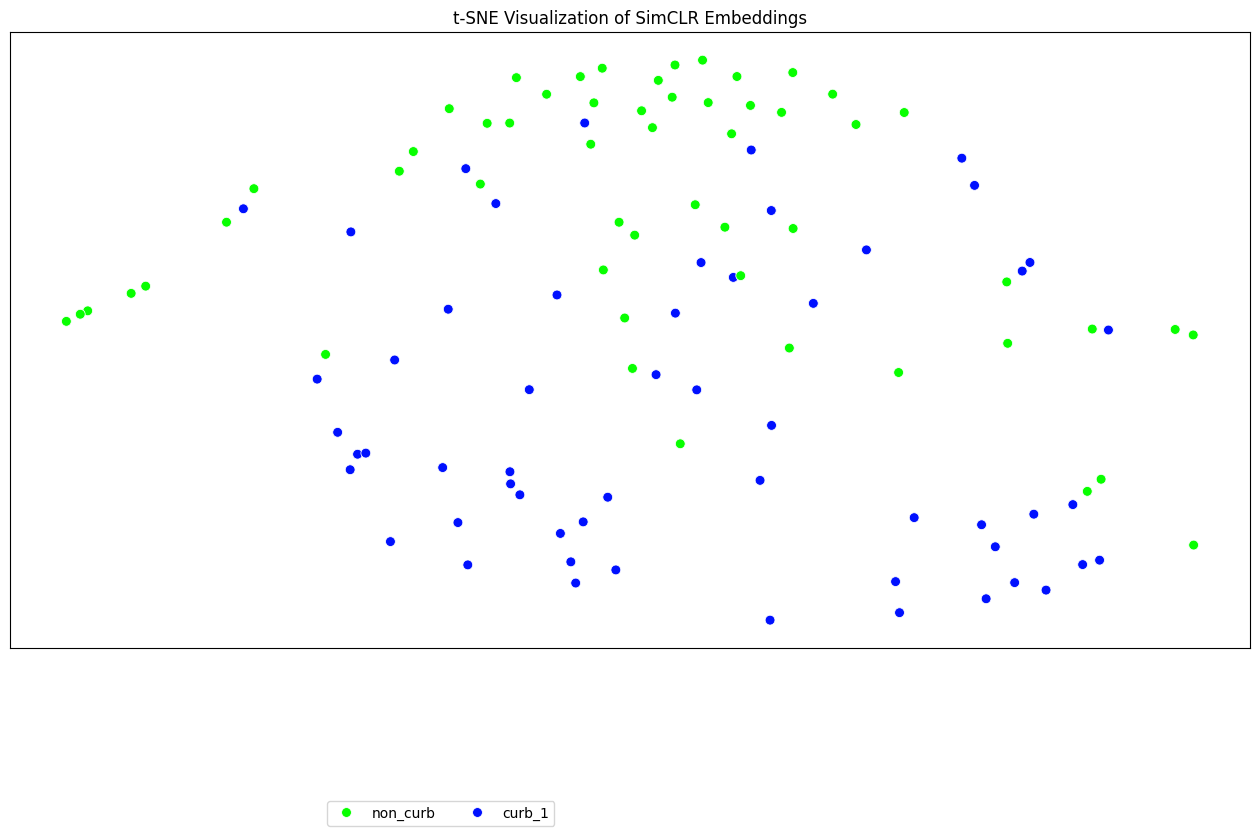

In [23]:
# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# If you have class names, use them for the legend
# Define your activity names if needed
label_list_full_name = ["non_curb", "curb_1"]  # Replace with your actual class names

# Update legend with class names if available
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():  # Check if variable exists
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)